In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,UpSampling2D, LeakyReLU, BatchNormalization
from tensorflow.keras.utils import plot_model
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models


2026-04-25 10:59:46.814960: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-25 10:59:47.349242: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-25 10:59:49.911641: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/home/khaled/miniconda3/envs/tf/lib/:/home/khaled/miniconda3/envs/tf/lib/
2026-04-25 10:59:49.913

### load the dataset

In [2]:
df_train = pd.read_csv("/home/khaled/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1/Train.csv")
df_test = pd.read_csv("/home/khaled/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1/Test.csv")


### basic Info

In [3]:
df_train.shape

(39209, 8)

In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39209 entries, 0 to 39208
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Width    39209 non-null  int64 
 1   Height   39209 non-null  int64 
 2   Roi.X1   39209 non-null  int64 
 3   Roi.Y1   39209 non-null  int64 
 4   Roi.X2   39209 non-null  int64 
 5   Roi.Y2   39209 non-null  int64 
 6   ClassId  39209 non-null  int64 
 7   Path     39209 non-null  object
dtypes: int64(7), object(1)
memory usage: 2.4+ MB


In [5]:
df_train.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [6]:
df_train.describe()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId
count,39209.000000,39209.000000,39209.000000,39209.000000,39209.000000,39209.000000,39209.000000
mean,50.835880,50.328930,5.999515,5.962381,45.197302,44.728379,15.788390
std,24.306933,23.115423,1.475493,1.385440,23.060157,21.971145,12.013238
min,25.000000,25.000000,0.000000,5.000000,20.000000,20.000000,0.000000
25%,35.000000,35.000000,5.000000,5.000000,29.000000,30.000000,5.000000
50%,43.000000,43.000000,6.000000,6.000000,38.000000,38.000000,12.000000
75%,58.000000,58.000000,6.000000,6.000000,53.000000,52.000000,25.000000
max,243.000000,225.000000,20.000000,20.000000,223.000000,205.000000,42.000000


### variable Distributions|

<Axes: xlabel='Width', ylabel='Count'>

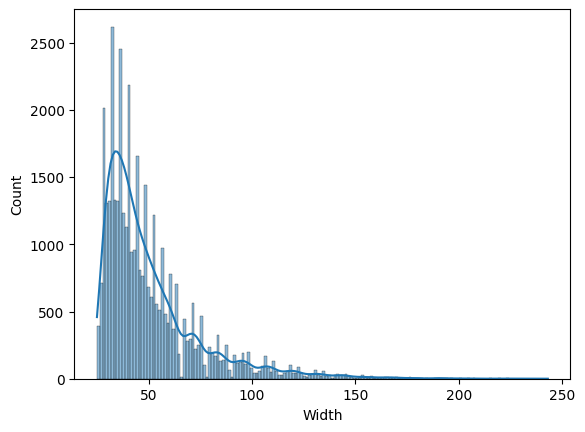

In [7]:
sns.histplot(data = df_train, x = 'Width', kde = True)

<Axes: xlabel='Height', ylabel='Count'>

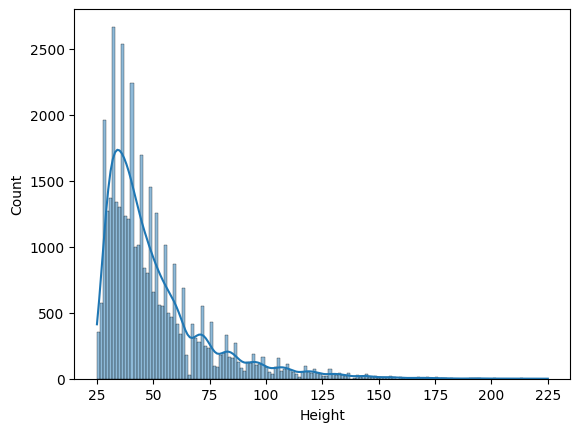

In [8]:
sns.histplot(data = df_train, x = 'Height', kde = True)

Text(0, 0.5, 'Count')

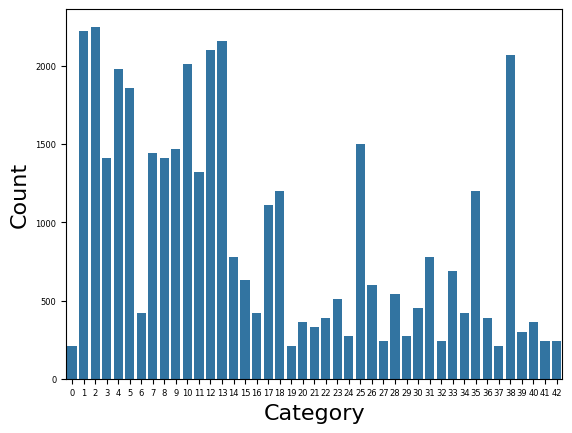

In [9]:
ax = sns.countplot(data = df_train, x = 'ClassId')
ax.tick_params(axis='both', labelsize=6)
ax.set_xlabel('Category', fontsize=16)
ax.set_ylabel('Count', fontsize=16)

In [10]:
value_count = df_train['ClassId'].value_counts() / len(df_train)
print(value_count.sort_values(ascending= False))

ClassId
2     0.057385
1     0.056620
13    0.055089
12    0.053559
38    0.052794
10    0.051264
4     0.050499
5     0.047438
25    0.038257
9     0.037491
7     0.036726
3     0.035961
8     0.035961
11    0.033666
18    0.030605
35    0.030605
17    0.028310
14    0.019893
31    0.019893
33    0.017572
15    0.016068
26    0.015303
28    0.013772
23    0.013007
30    0.011477
16    0.010712
6     0.010712
34    0.010712
22    0.009947
36    0.009947
40    0.009182
20    0.009182
21    0.008416
39    0.007651
29    0.006886
24    0.006886
32    0.006121
27    0.006121
41    0.006121
42    0.006121
37    0.005356
0     0.005356
19    0.005356
Name: count, dtype: float64


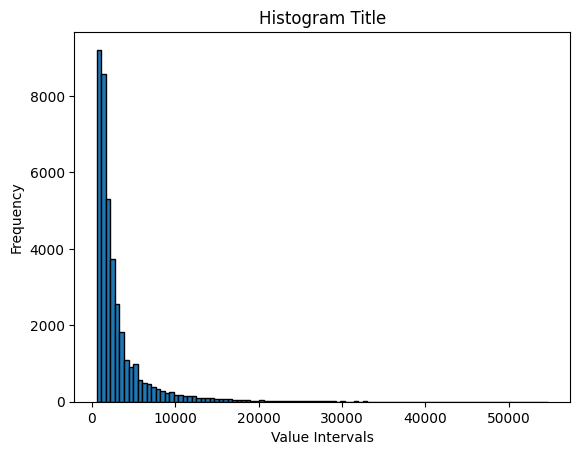

In [11]:
plt.hist(df_train["Height"]*df_train["Width"], bins=100, edgecolor='black')
plt.title('Histogram Title')
plt.xlabel('Value Intervals')
plt.ylabel('Frequency')
plt.show()

### Load Images

In [12]:
base_path = "/home/khaled/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1"
def load_images(df, target_size=(32, 32)):
    images = []
    labels = []
    for idx in range(df.shape[0]):
        roi = df.iloc[idx,2:6]
        img_path = os.path.join(base_path,df.loc[idx,"Path"])
        with Image.open(img_path) as img:
            crop_box = (roi["Roi.X1"],roi["Roi.Y1"],roi["Roi.X2"],roi["Roi.Y2"])
            img = img.crop(crop_box)
            img = img.resize(target_size)
            images.append(img)
            labels.append(df.loc[idx,"ClassId"])
    return np.array(images), np.array(labels)


In [13]:
X_train,y_train = load_images(df_train)
X_test,y_test = load_images(df_test)

In [14]:
print(len(X_train), len(y_train))

39209 39209


### Sample Img per class

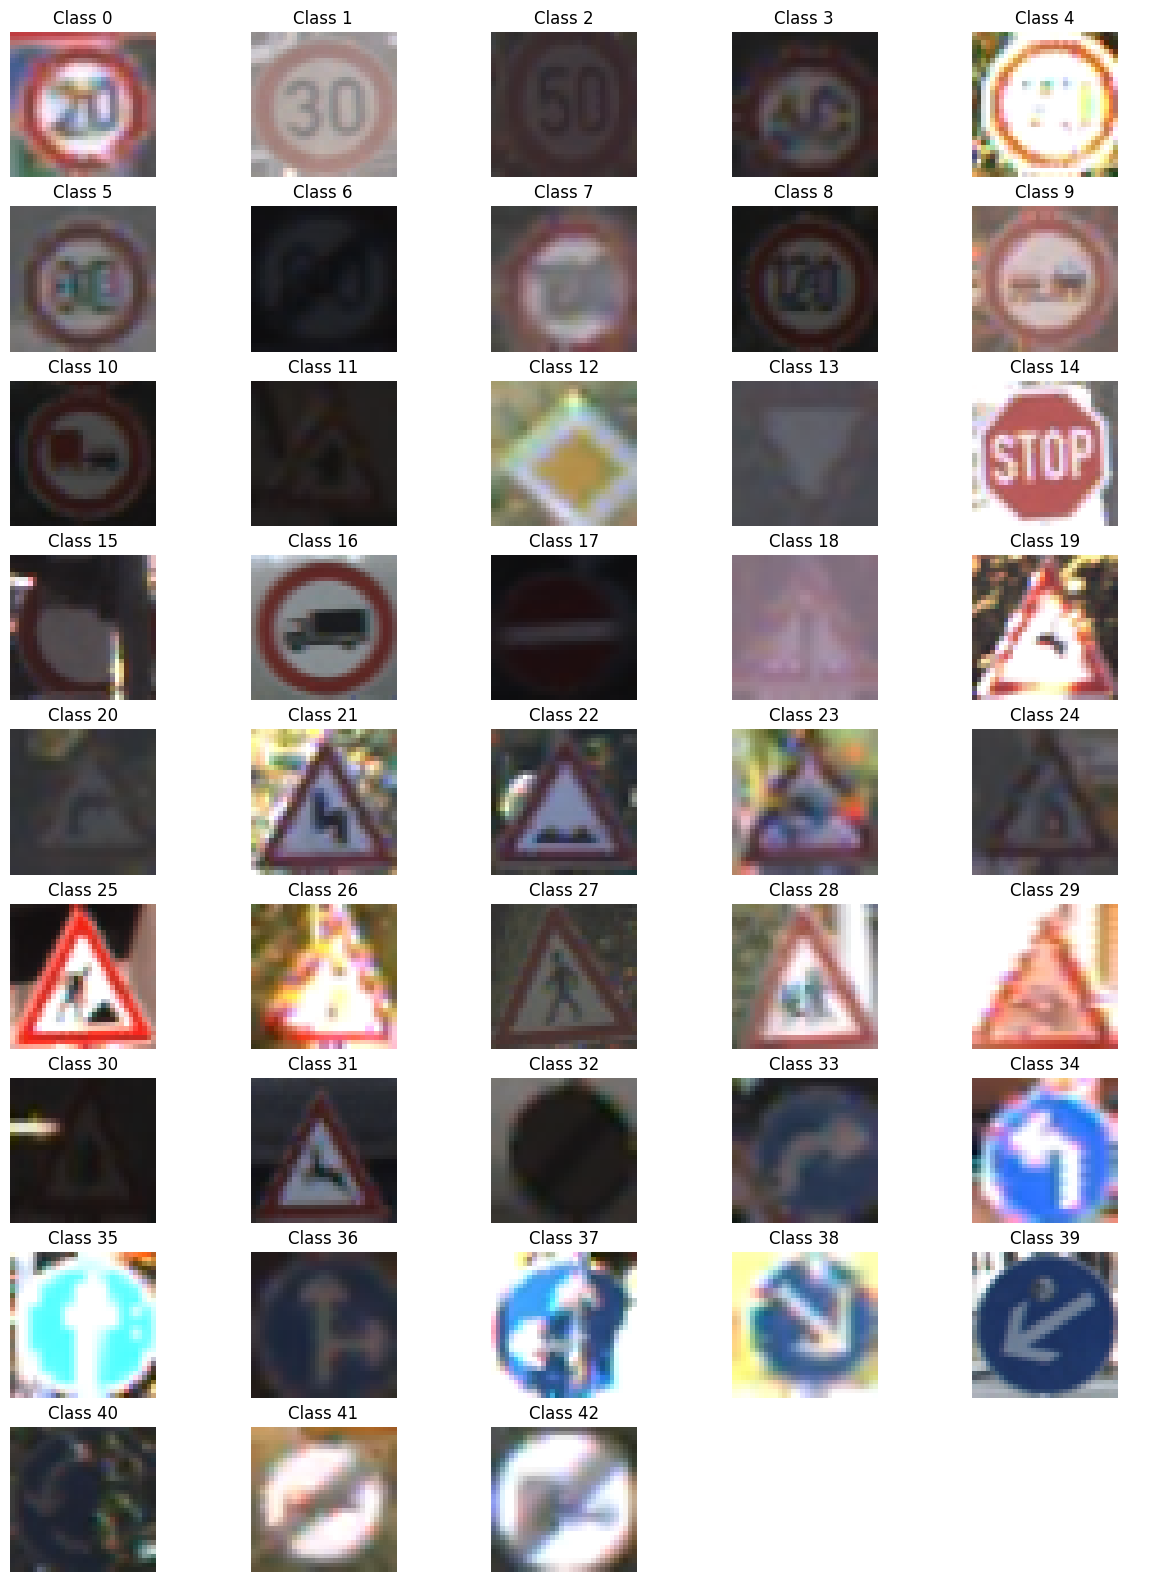

In [15]:
fig, axes = plt.subplots(9, 5, figsize= (15, 20))
for i, ax in enumerate(axes.flatten()):
  if i > 42:
    ax.axis('off')
    continue
  img = X_train[y_train == i][0]
  ax.imshow(img)
  ax.set_title(f'Class {i}')
  ax.axis('off')

### Pixels stats

In [16]:
def pixel_stats(X):

  flatten_img = X.flatten()
  Stats = {
      'mean': [np.mean(flatten_img)],
      'median': [np.median(flatten_img)],
      'std': [np.std(flatten_img)],
      'max': [np.max(flatten_img)],
      'min': [np.min(flatten_img)],
  }
  return pd.DataFrame(Stats)

In [17]:
stats = pixel_stats(X_train)
stats = stats.T.rename(columns={0: 'value'})
print(stats)

             value
mean     85.972866
median   63.000000
std      68.114775
max     255.000000
min       0.000000


In [18]:
#Flattening
images = X_train.reshape(X_train.shape[0], -1)
labels = y_train
images = images / 255
scaler = StandardScaler()
images_scaled = scaler.fit_transform(images)

In [19]:
#PCA implementation
pca = PCA(n_components=100)
image_pca = pca.fit_transform(images_scaled)
print(image_pca.shape)

#LDA implementation
lda = LDA(n_components=2)
image_lda = lda.fit_transform(image_pca, labels)
print(image_lda.shape)

(39209, 100)
(39209, 2)


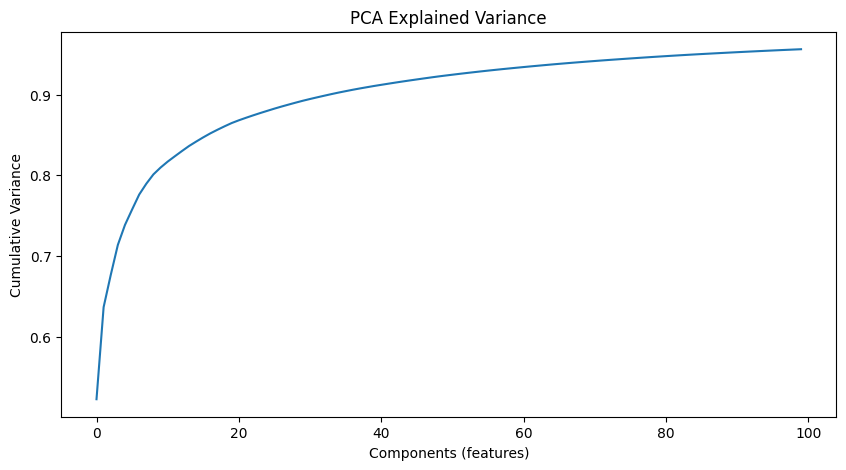

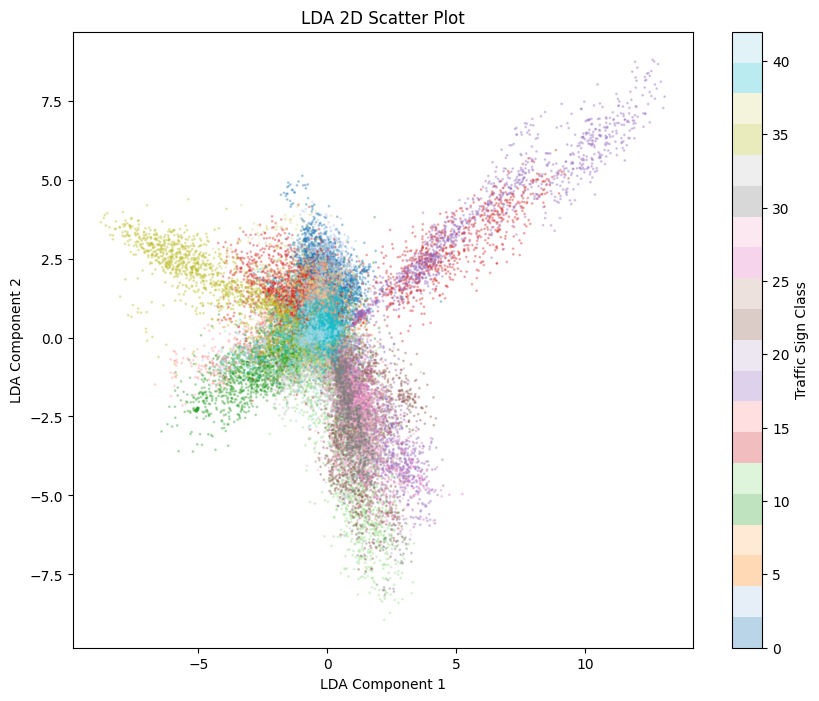

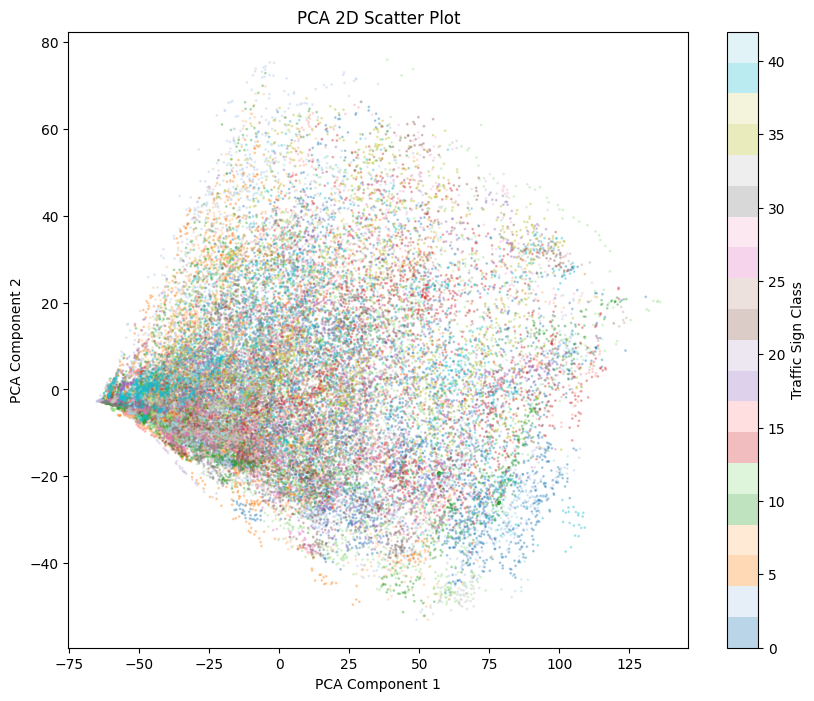

In [22]:
#Plot 1 : PCA explained variance
plt.figure(figsize=(10,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title('PCA Explained Variance')
plt.xlabel('Components (features)')
plt.ylabel('Cumulative Variance')
plt.show()

#Plot 2 : LDA 2D Scatter Plot
plt.figure(figsize=(10,8))
plt.scatter(image_lda[:,0], image_lda[:,1], c=labels, cmap='tab20', alpha=0.3, s=1)
plt.title('LDA 2D Scatter Plot')
plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.colorbar(label='Traffic Sign Class')
plt.show()


#Plot 3 : PCA 2D Scatter Plot
plt.figure(figsize=(10,8))
plt.scatter(image_pca[:,0], image_pca[:,1], c=labels, cmap='tab20', alpha=0.3, s=1)
plt.title('PCA 2D Scatter Plot')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Traffic Sign Class')
plt.show()

In [23]:



# Flatten and scale test images the same way as training
X_test_flat = X_test.reshape(X_test.shape[0], -1) / 255
X_test_scaled = scaler.transform(X_test_flat)

In [24]:



# -------------------------
# 1. Naive Bayes Classifier
# -------------------------
nb_clf = GaussianNB()
nb_clf.fit(images_scaled, labels)
y_pred_nb = nb_clf.predict(X_test_scaled)

print("=== Naive Bayes Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))


=== Naive Bayes Performance ===
Accuracy: 0.19034045922406967

Classification Report:
               precision    recall  f1-score   support

           0       0.04      0.37      0.08        60
           1       0.30      0.30      0.30       720
           2       0.23      0.11      0.15       750
           3       0.12      0.24      0.16       450
           4       0.00      0.00      0.00       660
           5       0.15      0.19      0.17       630
           6       0.04      0.76      0.07       150
           7       0.09      0.10      0.09       450
           8       0.07      0.08      0.07       450
           9       0.64      0.14      0.22       480
          10       0.00      0.00      0.00       660
          11       0.52      0.03      0.05       420
          12       0.99      0.19      0.31       690
          13       0.53      0.46      0.49       720
          14       0.86      0.44      0.58       270
          15       0.40      0.32      0.36     

In [25]:


# -------------------------
# 2. KNN Classifier
# -------------------------
knn_clf = KNeighborsClassifier(n_neighbors=5)  # you can tune k
knn_clf.fit(images_scaled, labels)
y_pred_knn = knn_clf.predict(X_test_scaled)

print("=== KNN Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

=== KNN Performance ===
Accuracy: 0.5577197149643706

Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.27      0.26        60
           1       0.43      0.45      0.44       720
           2       0.37      0.37      0.37       750
           3       0.29      0.32      0.31       450
           4       0.48      0.52      0.50       660
           5       0.30      0.47      0.37       630
           6       0.58      0.51      0.55       150
           7       0.34      0.36      0.35       450
           8       0.39      0.36      0.37       450
           9       0.69      0.51      0.58       480
          10       0.76      0.75      0.76       660
          11       0.60      0.50      0.54       420
          12       0.92      0.76      0.83       690
          13       0.95      0.97      0.96       720
          14       0.99      0.72      0.83       270
          15       0.79      0.65      0.71       210
   

In [26]:
print(len(X_train), len(y_train))

39209 39209


In [27]:
from tensorflow.keras import Input
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Normalize images for CNN
X_train_cnn = X_train / 255.0
X_test_cnn = X_test / 255.0

model = Sequential([
    Input(shape=(32,32,3)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(43, activation='softmax')
])

model.compile(optimizer = tf.keras.optimizers.legacy.Adam(),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 batch_normalization (BatchN  (None, 32, 32, 32)       128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 16, 16, 64)       256       
 hNormalization)                                                 
                                                        

In [28]:
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-5
)

In [29]:
print(len(X_train_cnn), len(y_train))

39209 39209


In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Split
X_train_cnn, X_val_cnn, y_train, y_val = train_test_split(
    X_train_cnn, y_train, test_size=0.2, random_state=42
)

# Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1
)

datagen.fit(X_train_cnn)

# Training
history = model.fit(
    datagen.flow(X_train_cnn, y_train, batch_size=64),
    epochs=30,
    validation_data=(X_val_cnn, y_val),
    callbacks=[early_stop, reduce_lr]
)

# Test
test_loss, test_acc = model.evaluate(X_test_cnn, y_test)
print(test_acc)

Epoch 1/30
491/491 [==============================] - 29s 39ms/step - loss: 1.8612 - accuracy: 0.4654 - val_loss: 0.6444 - val_accuracy: 0.8076 - lr: 0.0010
Epoch 2/30
491/491 [==============================] - 17s 35ms/step - loss: 0.5390 - accuracy: 0.8275 - val_loss: 0.1255 - val_accuracy: 0.9614 - lr: 0.0010
Epoch 3/30
491/491 [==============================] - 17s 35ms/step - loss: 0.2775 - accuracy: 0.9135 - val_loss: 0.0272 - val_accuracy: 0.9925 - lr: 0.0010
Epoch 4/30
491/491 [==============================] - 18s 36ms/step - loss: 0.1861 - accuracy: 0.9423 - val_loss: 0.0298 - val_accuracy: 0.9897 - lr: 0.0010
Epoch 5/30
491/491 [==============================] - 18s 36ms/step - loss: 0.1589 - accuracy: 0.9508 - val_loss: 0.0310 - val_accuracy: 0.9899 - lr: 0.0010
Epoch 6/30
491/491 [==============================] - 17s 35ms/step - loss: 0.1264 - accuracy: 0.9619 - val_loss: 0.0156 - val_accuracy: 0.9949 - lr: 0.0010
Epoch 7/30
491/491 [==============================] - 17s 

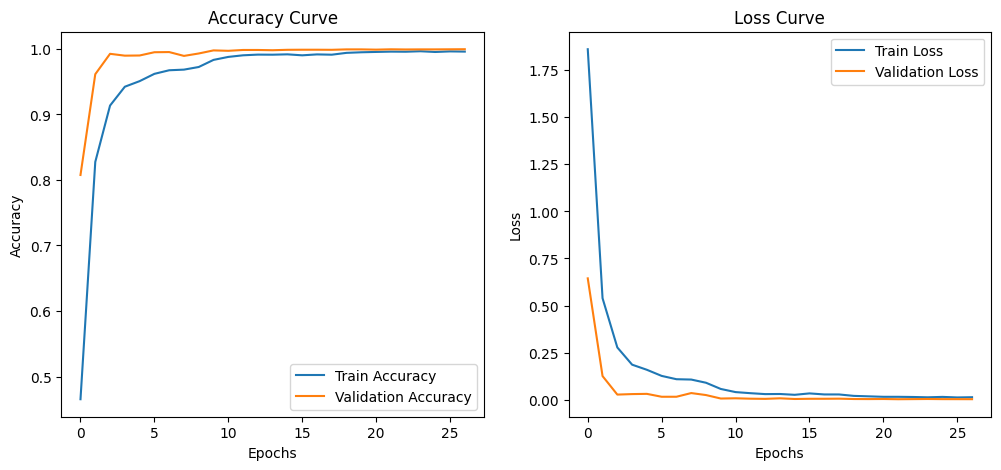

In [31]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [32]:
plot_model(model, to_file='cnn_architecture.png', show_shapes=True, show_layer_names=True)
test_loss, test_acc = model.evaluate(X_test_cnn, y_test)
print("CNN Test Accuracy:", test_acc)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.
395/395 [==============================] - 3s 7ms/step - loss: 0.0824 - accuracy: 0.9834
CNN Test Accuracy: 0.9833729267120361


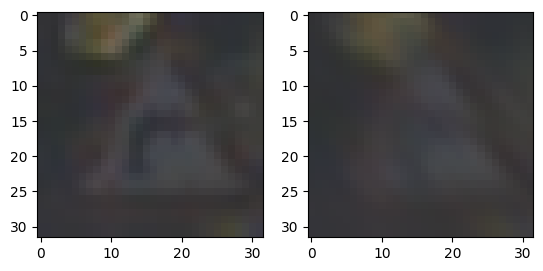

In [33]:
import cv2

def apply_custom_kernel(image, kernel_matrix):
    kernel = np.array(kernel_matrix, dtype=np.float32)
    return cv2.filter2D(image, -1, kernel)

motion_blur_kernel = [
    [0.2, 0, 0, 0, 0],
    [0, 0.2, 0, 0, 0],
    [0, 0, 0.2, 0, 0],
    [0, 0, 0, 0.2, 0],
    [0, 0, 0, 0, 0.2]
]

new_img = apply_custom_kernel(X_train[0],motion_blur_kernel)
plt.subplot(121)
plt.imshow(X_train[0])
plt.subplot(122)
plt.imshow(new_img)

In [34]:
def add_noise(data):
    noised_data = []
    for img in data:
        noised_data.append(np.clip(apply_custom_kernel(img,motion_blur_kernel),0,255).astype(np.uint8))
    return np.array(noised_data)

In [35]:
y_train_denoise = X_train.copy()
x_train_denoise = add_noise(y_train_denoise)
x_train_denoise = x_train_denoise/255
y_train_denoise = y_train_denoise/255
x_train_denoise = x_train_denoise.reshape(-1,32,32,3)
y_train_denoise = y_train_denoise.reshape(-1,32,32,3)

In [39]:
autoencoder_model =  Sequential([
    Conv2D(32, (3,3), padding="same",input_shape=(32,32,3)),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    MaxPooling2D((2,2),strides=2),
    Conv2D(64, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    Conv2D(64, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    Conv2D(128, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    UpSampling2D(size=(2,2)),
    Conv2D(64, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    Conv2D(64, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    UpSampling2D(size=(2,2)),
    Conv2D(32, (3,3),padding="same"),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),
    Conv2D(3, (3,3),activation="sigmoid",padding="same")
])
autoencoder_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 32, 32, 32)        896       
                                                                 
 batch_normalization_3 (Batc  (None, 32, 32, 32)       128       
 hNormalization)                                                 
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 32, 32, 32)        0         
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 16, 16, 32)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 batch_normalization_4 (Batc  (None, 16, 16, 64)      

In [ ]:
autoencoder_model.compile(optimizer="adam",loss="mse",metrics=["mae"])
history = autoencoder_model.fit(x_train_denoise,y_train_denoise,batch_size=32,epochs=20)

In [ ]:
autoencoder_model.save("/kaggle/working/autoencoder_model.keras")

In [ ]:
print(f'number of classes: {len(np.unique(y_train))}')

number of classes: 43


In [20]:
IMG_SIZE = (96, 96)
CHANNELS = 3
NUM_CLASSES = 43
X_train_scaled = (X_train / 127.5) - 1.0
X_test_scaled = (X_test / 127.5) - 1.0
base_model_pretrained = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS))
base_model_pretrained.trainable = False 
pre_trained = models.Sequential([
    layers.Resizing(IMG_SIZE[0], IMG_SIZE[1]),
    
    base_model_pretrained,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation='softmax')
])


pre_trained.compile(tf.keras.optimizers.legacy.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Starting Training: Pretrained Model...")
history_pretrained = pre_trained.fit(X_train_scaled, y_train, batch_size=32,epochs=10, validation_data=(X_test_scaled, y_test))

base_model_tuning = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS))
base_model_tuning.trainable = True

fine_tune_at = 100
for layer in base_model_tuning.layers[:fine_tune_at]:
    layer.trainable = False

tuning= models.Sequential([
    layers.Resizing(IMG_SIZE[0], IMG_SIZE[1]),
    
    base_model_tuning,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
tuning.compile(optimizer=tf.keras.optimizers.legacy.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Starting Training: Fine-tuning...")
history_finetuned = tuning.fit(X_train_scaled, y_train, batch_size=32, epochs=10, validation_data=(X_test_scaled, y_test))

2026-04-25 11:08:43.638602: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:967] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-25 11:08:43.751393: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:967] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-25 11:08:43.751529: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:967] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-25 11:08:43.755622: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other ope

Starting Training: Pretrained Model...
Epoch 1/10


2026-04-25 11:09:00.137058: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8100
2026-04-25 11:09:04.636593: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-25 11:09:04.735288: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-25 11:09:04.736853: W tensorflow/compiler/xla/stream_executor/gpu/asm_compiler.cc:85] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2026-04-25 11:09:04.826607: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-25 11:09:04.829653: W tensorflow/compiler/xla/stream_executor/gpu/redzone_allocator.cc:318] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.


   2/1226 [..............................] - ETA: 1:47 - loss: 4.5267 - accuracy: 0.0312       

2026-04-25 11:09:09.515514: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:630] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


1226/1226 [==============================] - 58s 33ms/step - loss: 0.8099 - accuracy: 0.7546 - val_loss: 0.6920 - val_accuracy: 0.7909
Epoch 2/10
1226/1226 [==============================] - 36s 30ms/step - loss: 0.3698 - accuracy: 0.8839 - val_loss: 0.6637 - val_accuracy: 0.8025
Epoch 3/10
1226/1226 [==============================] - 37s 30ms/step - loss: 0.2932 - accuracy: 0.9040 - val_loss: 0.6574 - val_accuracy: 0.8151
Epoch 4/10
1226/1226 [==============================] - 36s 29ms/step - loss: 0.2627 - accuracy: 0.9136 - val_loss: 0.6719 - val_accuracy: 0.8090
Epoch 5/10
1226/1226 [==============================] - 36s 30ms/step - loss: 0.2384 - accuracy: 0.9186 - val_loss: 0.6903 - val_accuracy: 0.8151
Epoch 6/10
1226/1226 [==============================] - 36s 29ms/step - loss: 0.2276 - accuracy: 0.9227 - val_loss: 0.7409 - val_accuracy: 0.8054
Epoch 7/10
1226/1226 [==============================] - 37s 30ms/step - loss: 0.2129 - accuracy: 0.9278 - val_loss: 0.7442 - val_accura

2026-04-25 11:15:29.853856: W tensorflow/tsl/framework/bfc_allocator.cc:290] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1007.56MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-25 11:15:29.854875: W tensorflow/tsl/framework/bfc_allocator.cc:290] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1007.56MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-25 11:15:29.889584: W tensorflow/tsl/framework/bfc_allocator.cc:290] Allocator (GPU_0_bfc) ran out of memory trying to allocate 917.41MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-25 11:15:29.889673: W tensorflow/tsl/framework/bfc_allocator.cc:290] Alloca

1224/1226 [============================>.] - ETA: 0s - loss: 0.2699 - accuracy: 0.9212

2026-04-25 11:16:17.824673: W tensorflow/tsl/framework/bfc_allocator.cc:290] Allocator (GPU_0_bfc) ran out of memory trying to allocate 942.88MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-25 11:16:17.824769: W tensorflow/tsl/framework/bfc_allocator.cc:290] Allocator (GPU_0_bfc) ran out of memory trying to allocate 942.88MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


1226/1226 [==============================] - 65s 48ms/step - loss: 0.2698 - accuracy: 0.9212 - val_loss: 3.2412 - val_accuracy: 0.6325
Epoch 2/10
1226/1226 [==============================] - 56s 45ms/step - loss: 0.0811 - accuracy: 0.9761 - val_loss: 0.4220 - val_accuracy: 0.9408
Epoch 3/10
1226/1226 [==============================] - 53s 44ms/step - loss: 0.0657 - accuracy: 0.9810 - val_loss: 0.4805 - val_accuracy: 0.9277
Epoch 4/10
1226/1226 [==============================] - 51s 42ms/step - loss: 0.0443 - accuracy: 0.9867 - val_loss: 0.4551 - val_accuracy: 0.9243
Epoch 5/10
1226/1226 [==============================] - 51s 41ms/step - loss: 0.0434 - accuracy: 0.9879 - val_loss: 0.4735 - val_accuracy: 0.9350
Epoch 6/10
1226/1226 [==============================] - 51s 42ms/step - loss: 0.0361 - accuracy: 0.9896 - val_loss: 0.6673 - val_accuracy: 0.9086
Epoch 7/10
1226/1226 [==============================] - 53s 43ms/step - loss: 0.0295 - accuracy: 0.9914 - val_loss: 0.2544 - val_accura

## Pretrained vs fine-tuned
| Model State | Optimizer | Training Loss | Training Accuracy | Validation Loss | validation Accuracy |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Pretrained (Frozen)** | Adam | 0.1948 | 0.9325 | 0.8452  | 0.7967 |
| **Fine-tuned (Unfrozen)** | Adam | 0.0182  | 0.9944  | 0.2067  | 0.9618 |